# Playing under a magnifying glass 

# Main goal
**Using a historical dataset of popular video games, this data project analyzes trends in the gaming industry to support game developers’ decision-making. The analysis focuses on identifying shifts in genre popularity, gaps between game ownership and active play, and understanding which types of games successfully drive player engagement rather than just sales** 

## In this EDA project we will gain insights about gaming trends and try to answer the following questions:
1.  **Does a company’s and a game's level of popularity necessarily indicate a high rating ?**
2.  **Which genres were popular in the past and have regained popularity in recent years ?**
3.  **Which games succeed in getting people to actually play (rather than getting access ) ?**

In [53]:
# Importing necessary libraries

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import plotly.express as px # Visualizations
import plotly.graph_objects as go
import seaborn as sns # Visualizations
import matplotlib.pyplot as plt # Visualizations
import ast # Cleaning


import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))


/kaggle/input/datasets/arnabchaki/popular-video-games-1980-2023/games.csv
/kaggle/input/datasets/eyalezra1986/popular-games-since-the-80s/games.csv


In [54]:
# Loading the csv file into Pandas
df = pd.read_csv("/kaggle/input/datasets/arnabchaki/popular-video-games-1980-2023/games.csv")
df

,Unnamed: 0,Title,Release Date,Team,Rating,Times Listed,Number of Reviews,Genres,Summary,Reviews,Plays,Playing,Backlogs,Wishlist
0,0,Elden Ring,"Feb 25, 2022","['Bandai Namco Entertainment', 'FromSoftware']",4.5,3.9K,3.9K,"['Adventure', 'RPG']","Elden Ring is a fantasy, action and open world...","[""The first playthrough of elden ring is one o...",17K,3.8K,4.6K,4.8K
1,1,Hades,"Dec 10, 2019",['Supergiant Games'],4.3,2.9K,2.9K,"['Adventure', 'Brawler', 'Indie', 'RPG']",A rogue-lite hack and slash dungeon crawler in...,['convinced this is a roguelike for people who...,21K,3.2K,6.3K,3.6K
2,2,The Legend of Zelda: Breath of the Wild,"Mar 03, 2017","['Nintendo', 'Nintendo EPD Production Group No...",4.4,4.3K,4.3K,"['Adventure', 'RPG']",The Legend of Zelda: Breath of the Wild is the...,['This game is the game (that is not CS:GO) th...,30K,2.5K,5K,2.6K
3,3,Undertale,"Sep 15, 2015","['tobyfox', '8-4']",4.2,3.5K,3.5K,"['Adventure', 'Indie', 'RPG', 'Turn Based Stra...","A small child falls into the Underground, wher...",['soundtrack is tied for #1 with nier automata...,28K,679,4.9K,1.8K
4,4,Hollow Knight,"Feb 24, 2017",['Team Cherry'],4.4,3K,3K,"['Adventure', 'Indie', 'Platform']",A 2D metroidvania with an emphasis on close co...,"[""this games worldbuilding is incredible, with...",21K,2.4K,8.3K,2.3K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1507,1507,Back to the Future: The Game,"Dec 22, 2010",['Telltale Games'],3.2,94,94,"['Adventure', 'Point-and-Click']",Back to the Future: The Game is one of Telltal...,['Very enjoyable game. The story adds onto the...,763,5,223,67
1508,1508,Team Sonic Racing,"May 21, 2019","['Sumo Digital', 'Sega']",2.9,264,264,"['Arcade', 'Racing']",Team Sonic Racing combines the best elements o...,"['jogo morto mas bom', 'not my cup of tea', ""C...",1.5K,49,413,107
1509,1509,Dragon's Dogma,"May 22, 2012",['Capcom'],3.7,210,210,"['Brawler', 'RPG']","Set in a huge open world, Dragon’s Dogma: Dark...","['Underrated.', 'A grandes rasgos, es como un ...",1.1K,45,487,206
1510,1510,Baldur's Gate 3,"Oct 06, 2020",['Larian Studios'],4.1,165,165,"['Adventure', 'RPG', 'Strategy', 'Tactical', '...","An ancient evil has returned to Baldur's Gate,...",['Bu türe bu oyunla girmeye çalışmak hataydı s...,269,79,388,602


In [55]:
# Getting an overiview of the data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1512 entries, 0 to 1511
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         1512 non-null   int64  
 1   Title              1512 non-null   object 
 2   Release Date       1512 non-null   object 
 3   Team               1511 non-null   object 
 4   Rating             1499 non-null   float64
 5   Times Listed       1512 non-null   object 
 6   Number of Reviews  1512 non-null   object 
 7   Genres             1512 non-null   object 
 8   Summary            1511 non-null   object 
 9   Reviews            1512 non-null   object 
 10  Plays              1512 non-null   object 
 11  Playing            1512 non-null   object 
 12  Backlogs           1512 non-null   object 
 13  Wishlist           1512 non-null   object 
dtypes: float64(1), int64(1), object(12)
memory usage: 165.5+ KB


**In order to work with the data correctly,first we have to convert it to the desirable type.**

In [56]:
# Converting data types

# Datetime
df["Release Date"] = pd.to_datetime(df["Release Date"],errors="coerce",format="%b %d, %Y")
# Numeric values
 # Dedictaed function which removes "k" and transforms into integers
def convert_plays(value):
    if pd.isna(value):
        return 0
    value = str(value)
    if "K" in value:
        return int(float(value.replace("K", "")) * 1000)
    return int(value)
# Using this function for all the necessary columns
df["Times Listed"] = df["Times Listed"].apply(convert_plays)
df["Number of Reviews"] = df["Number of Reviews"].apply(convert_plays)
df["Plays"] = df["Plays"].apply(convert_plays)
df["Playing"] = df["Playing"].apply(convert_plays)
df["Backlogs"] = df["Backlogs"].apply(convert_plays)
df["Wishlist"] = df["Wishlist"].apply(convert_plays)


    
    
   


In [57]:
# Getting a second overiview of the data after changes
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1512 entries, 0 to 1511
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Unnamed: 0         1512 non-null   int64         
 1   Title              1512 non-null   object        
 2   Release Date       1509 non-null   datetime64[ns]
 3   Team               1511 non-null   object        
 4   Rating             1499 non-null   float64       
 5   Times Listed       1512 non-null   int64         
 6   Number of Reviews  1512 non-null   int64         
 7   Genres             1512 non-null   object        
 8   Summary            1511 non-null   object        
 9   Reviews            1512 non-null   object        
 10  Plays              1512 non-null   int64         
 11  Playing            1512 non-null   int64         
 12  Backlogs           1512 non-null   int64         
 13  Wishlist           1512 non-null   int64         
dtypes: datet

**A main view of the statistics.**

In [58]:
# viewing a summarry statistics
df.describe()

,Unnamed: 0,Release Date,Rating,Times Listed,Number of Reviews,Plays,Playing,Backlogs,Wishlist
count,1512.000000,1509,1499.000000,1512.000000,1512.000000,1512.000000,1512.000000,1512.000000,1512.000000
mean,755.500000,2012-09-16 19:03:13.240556800,3.719346,769.459656,769.459656,6253.578704,267.379630,1452.577381,780.540344
min,0.000000,1980-05-22 00:00:00,0.700000,0.000000,0.000000,0.000000,0.000000,1.000000,2.000000
25%,377.750000,2007-09-16 00:00:00,3.400000,284.000000,284.000000,1800.000000,43.000000,461.750000,212.000000
50%,755.500000,2014-09-01 00:00:00,3.800000,551.000000,551.000000,4200.000000,112.500000,1000.000000,496.000000
75%,1133.250000,2019-09-13 00:00:00,4.100000,1000.000000,1000.000000,9100.000000,298.000000,2100.000000,1100.000000
max,1511.000000,2025-03-31 00:00:00,4.800000,4300.000000,4300.000000,33000.000000,3800.000000,8300.000000,5400.000000
std,436.621117,NaN,0.532608,687.840871,687.840871,5894.977122,426.453368,1341.971968,801.253431


# Data cleaning:

**In this section i will find missing values,duplicates,unnecessary columns. i will handle outliers and clean the text.** 

In [59]:
# Finding missing values
df.isnull().sum()


Unnamed: 0            0
Title                 0
Release Date          3
Team                  1
Rating               13
Times Listed          0
Number of Reviews     0
Genres                0
Summary               1
Reviews               0
Plays                 0
Playing               0
Backlogs              0
Wishlist              0
dtype: int64

In [60]:

# Filling missing text
df["Summary"] = df["Summary"].fillna("Unknown")
df["Team"] = df["Team"].fillna("Unknown")

# Filling missing ratings with the median (because ratings can be slightly skewed)
df["Rating"] = df["Rating"].fillna(df["Rating"].median())


In [61]:
# Dropping missing release dates (there are only 3 out of 1512, so it will not affect the destribution)
df = df.dropna(subset=["Release Date"])

df.isnull().sum()

Unnamed: 0           0
Title                0
Release Date         0
Team                 0
Rating               0
Times Listed         0
Number of Reviews    0
Genres               0
Summary              0
Reviews              0
Plays                0
Playing              0
Backlogs             0
Wishlist             0
dtype: int64

**We can see that the columns "Times listed" and "Number of reviews" have the same values, it does not make a lot of sense, it is probably a mistake in gathering the data,so lets remove it.**

In [62]:
# Dropping unnecessary columns
df = df.drop(columns=["Unnamed: 0","Number of Reviews"])


In [63]:
# Finding duplicates
duplicates = df[df.duplicated()]
print(f" There are {len(duplicates)} duplicates in the dataframe.")

 There are 382 duplicates in the dataframe.


In [64]:
# Dropping duplicates
df = df.drop_duplicates()
print(f" There are {df.duplicated().sum()} duplicates in the dataframe.")

 There are 0 duplicates in the dataframe.


**Cleaning the text**

In [65]:
# Getting rid out of unnecessary signs
df["Reviews"] = df["Reviews"].str.replace(r"['\"`]", "", regex=True)

# Convert string list to actual list
df["Genres"] = df["Genres"].apply(ast.literal_eval)

# Join list into a clean string
df["Genres"] = df["Genres"].apply(lambda x: ", ".join(x))

# Getting rid out of unnecessary signs
df["Genres"] = df["Genres"].str.replace("[']", "", regex=True)

df["Team"] = df["Team"].str.replace(r"['\"`]", "", regex=True)


def clean_list_column(x):
    # If it's already a list, keep it
    if isinstance(x, list):
        return ", ".join(x)  # join into string
    # If it's a string that looks like a list
    elif isinstance(x, str):
        # Remove brackets and quotes manually
        x = x.strip("[]")  # remove [ and ]
        # Remove single/double quotes
        x = x.replace("'", "").replace('"', "")
        # Split by comma if multiple items
        items = [item.strip() for item in x.split(",") if item.strip()]
        return ", ".join(items)
    # If missing or something else
    else:
        return ""

# Apply to both columns
df["Genres"] = df["Genres"].apply(clean_list_column)
df["Team"] = df["Team"].apply(clean_list_column)

df

,Title,Release Date,Team,Rating,Times Listed,Genres,Summary,Reviews,Plays,Playing,Backlogs,Wishlist
0,Elden Ring,2022-02-25,"Bandai Namco Entertainment, FromSoftware",4.5,3900,"Adventure, RPG","Elden Ring is a fantasy, action and open world...",[The first playthrough of elden ring is one of...,17000,3800,4600,4800
1,Hades,2019-12-10,Supergiant Games,4.3,2900,"Adventure, Brawler, Indie, RPG",A rogue-lite hack and slash dungeon crawler in...,[convinced this is a roguelike for people who ...,21000,3200,6300,3600
2,The Legend of Zelda: Breath of the Wild,2017-03-03,"Nintendo, Nintendo EPD Production Group No. 3",4.4,4300,"Adventure, RPG",The Legend of Zelda: Breath of the Wild is the...,[This game is the game (that is not CS:GO) tha...,30000,2500,5000,2600
3,Undertale,2015-09-15,"tobyfox, 8-4",4.2,3500,"Adventure, Indie, RPG, Turn Based Strategy","A small child falls into the Underground, wher...",[soundtrack is tied for #1 with nier automata....,28000,679,4900,1800
4,Hollow Knight,2017-02-24,Team Cherry,4.4,3000,"Adventure, Indie, Platform",A 2D metroidvania with an emphasis on close co...,"[this games worldbuilding is incredible, with ...",21000,2400,8300,2300
...,...,...,...,...,...,...,...,...,...,...,...,...
1507,Back to the Future: The Game,2010-12-22,Telltale Games,3.2,94,"Adventure, Point-and-Click",Back to the Future: The Game is one of Telltal...,[Very enjoyable game. The story adds onto the ...,763,5,223,67
1508,Team Sonic Racing,2019-05-21,"Sumo Digital, Sega",2.9,264,"Arcade, Racing",Team Sonic Racing combines the best elements o...,"[jogo morto mas bom, not my cup of tea, Compar...",1500,49,413,107
1509,Dragon's Dogma,2012-05-22,Capcom,3.7,210,"Brawler, RPG","Set in a huge open world, Dragon’s Dogma: Dark...","[Underrated., A grandes rasgos, es como un MMO...",1100,45,487,206
1510,Baldur's Gate 3,2020-10-06,Larian Studios,4.1,165,"Adventure, RPG, Strategy, Tactical, Turn Based...","An ancient evil has returned to Baldur's Gate,...",[Bu türe bu oyunla girmeye çalışmak hataydı sa...,269,79,388,602


**Handling outliers**

In [66]:
# finding outliers
numeric_cols = [
    'Rating', 
    'Times Listed',  
    'Plays', 
    'Playing', 
    'Backlogs', 
    'Wishlist'
]

outliers_dict = {}

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    outliers_dict[col] = outliers
    
    print(f"{col}: {len(outliers)} outliers")

Rating: 21 outliers
Times Listed: 69 outliers
Plays: 66 outliers
Playing: 121 outliers
Backlogs: 49 outliers
Wishlist: 85 outliers


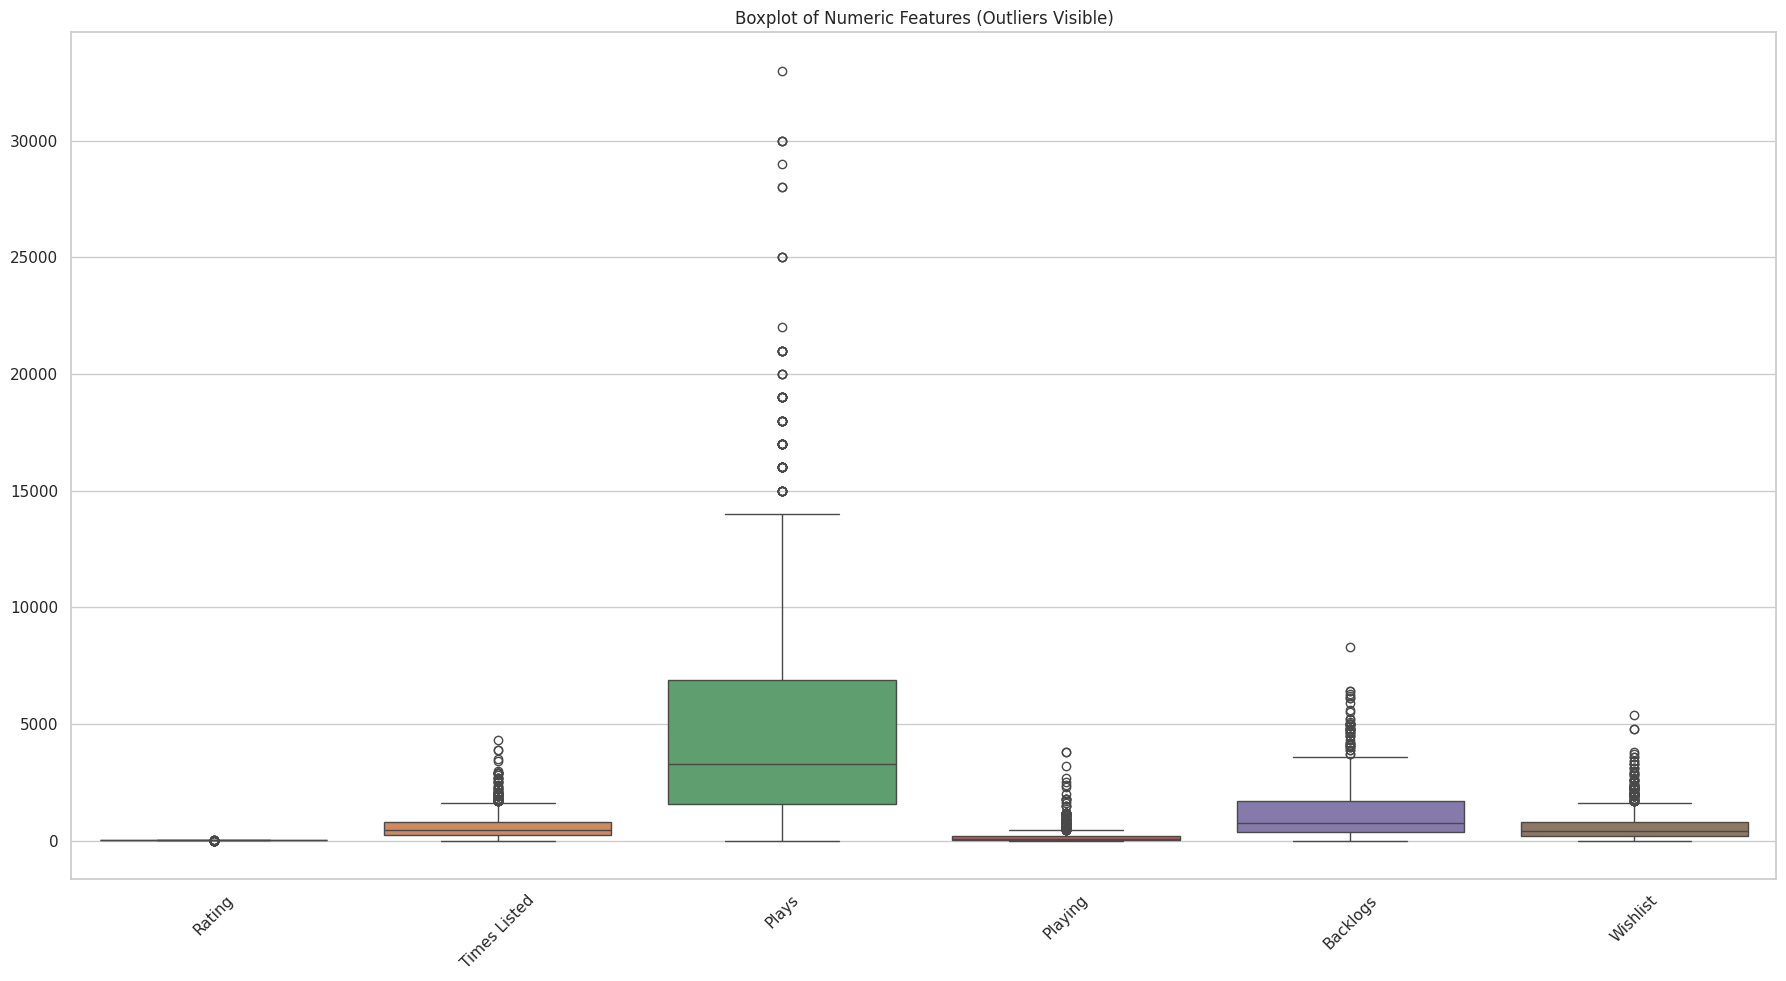

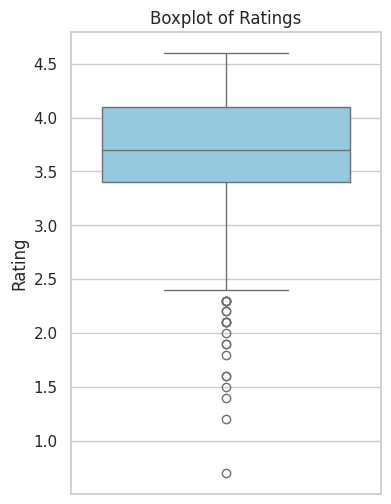

In [67]:
# visualize it so it is better to understand
plt.figure(figsize=(22, 11))
sns.boxplot(data=df[numeric_cols])
plt.xticks(rotation=45)
plt.title("Boxplot of Numeric Features (Outliers Visible)")
plt.show()

# boxplot for ratings only, different scale
plt.figure(figsize=(4, 6))
sns.boxplot(y=df['Rating'], color='skyblue')
plt.title("Boxplot of Ratings")
plt.ylabel("Rating")
plt.show()

**In this case it is better not to delete outliers, becasue they represent the most important games and a referance to others.**

#  EDA process

**To begin with, it is important to observe the distribution of the rating column in order to interpret correctly the following graphs.**

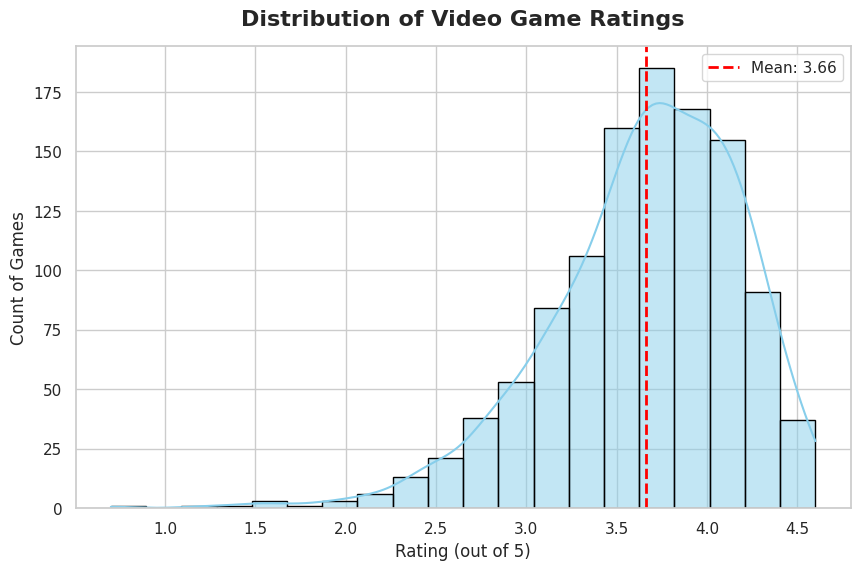

In [68]:
# Set the style and figuresize
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

# Create the histogram with a density curve (KDE)
sns.histplot(data=df, x='Rating', bins=20, kde=True, color='skyblue', edgecolor='black')

# Add a vertical line for the mean rating
rating_mean = df['Rating'].mean()
plt.axvline(rating_mean, color='red', linestyle='--', linewidth=2, label=f'Mean: {rating_mean:.2f}')

# Titles and labels
plt.title('Distribution of Video Game Ratings', fontsize=16, pad=15, fontweight='bold')
plt.xlabel('Rating (out of 5)', fontsize=12)
plt.ylabel('Count of Games', fontsize=12)
plt.legend()

# Display the plot
plt.show()

## popularity vs. ratings

**The "Hidden Gem" Outlier (High Rating, Low Popularity)
These are games that critics and players love, but have significantly lower "Listings" or "Reviews" than the major blockbusters.**
**The "Underperformer" Outliers (Low Rating, Low Popularity)In a dataset dominated by $4.0+$ ratings, these titles fall significantly below the average quality curve.**

In [69]:
# Calculate the mean (average) for comparison
mean_rating = df['Rating'].mean()
mean_listed = df['Times Listed'].mean()

# 1. Identify "Hidden Gems" 
# (High Quality AND Low Visibility)
hidden_gems = df[(df['Rating'] > mean_rating) & (df['Times Listed'] < mean_listed)]

# 2. Identify "Trend Breakers"
# (High Visibility but relatively Low Quality)
trend_breakers = df[(df['Times Listed'] > mean_listed) & (df['Rating'] < mean_rating)]

# 3. Sort for Insight
# For Hidden Gems: Sort by 'Times Listed' ASCENDING to see the most obscure first
hidden_gems_sorted = hidden_gems.sort_values(by='Times Listed', ascending=True)

# For Trend Breakers: Sort by 'Rating' ASCENDING to see the biggest disappointments first
trend_breakers_sorted = trend_breakers.sort_values(by='Rating', ascending=True)

print(f"--- THRESHOLDS: Rating > {mean_rating:.2f} | Times Listed < {mean_listed:.2f} ---")
print("\n--- HIDDEN GEMS (Most Obscure First) ---")
print(hidden_gems_sorted[['Title', 'Rating', 'Times Listed']])

print("\n--- TREND BREAKERS (Lowest Rated of the Popular Games) ---")
print(trend_breakers_sorted[['Title', 'Rating', 'Times Listed']])



--- THRESHOLDS: Rating > 3.66 | Times Listed < 618.16 ---

--- HIDDEN GEMS (Most Obscure First) ---
                               Title  Rating  Times Listed
1341                Pac-Man in a Tin     3.8             0
1349                    Pokémon Añil     3.8             2
1409           Better Call Saul Kart     4.2             8
1383         Megami Ibunroku Persona     3.7            16
1282            Super Mario Sunshine     3.7            19
...                              ...     ...           ...
204               No More Heroes III     3.9           604
1081                        Hitman 2     4.0           605
1101         Metroid Prime 2: Echoes     4.0           606
309   Fire Emblem: The Blazing Blade     3.7           609
1056                   The Messenger     3.8           613

[341 rows x 3 columns]

--- TREND BREAKERS (Lowest Rated of the Popular Games) ---
                                Title  Rating  Times Listed
947                   Devil May Cry 2     1.6   

**Correlation between different columns.**

Correlation between Popularity and Rating: 0.39


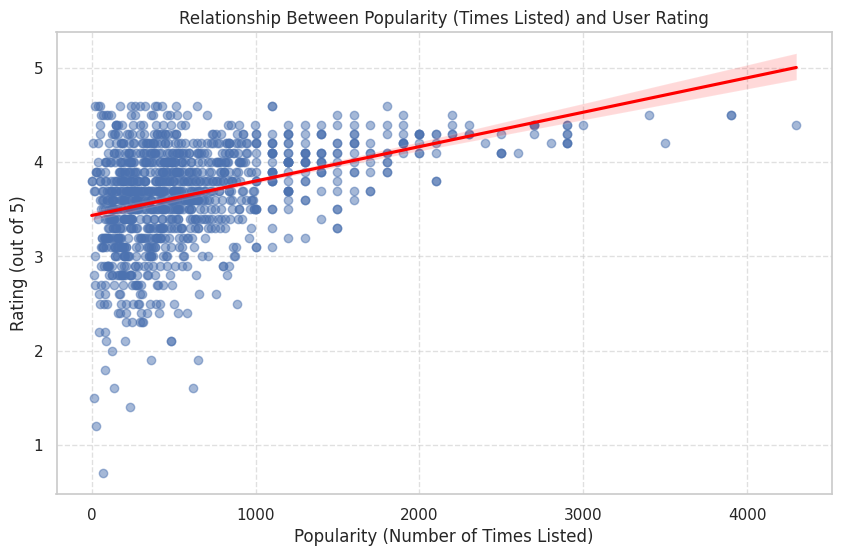

In [70]:
# 1. Calculate Correlation
# A value near 1 means strong positive correlation
# A value near 0 means no relationship
correlation = df['Rating'].corr(df['Times Listed'])
print(f"Correlation between Popularity and Rating: {correlation:.2f}")

# 2. Visualization
plt.figure(figsize=(10, 6))
sns.regplot(data=df, x='Times Listed', y='Rating', 
            scatter_kws={'alpha':0.5}, line_kws={'color':'red'})

plt.title('Relationship Between Popularity (Times Listed) and User Rating')
plt.xlabel('Popularity (Number of Times Listed)')
plt.ylabel('Rating (out of 5)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

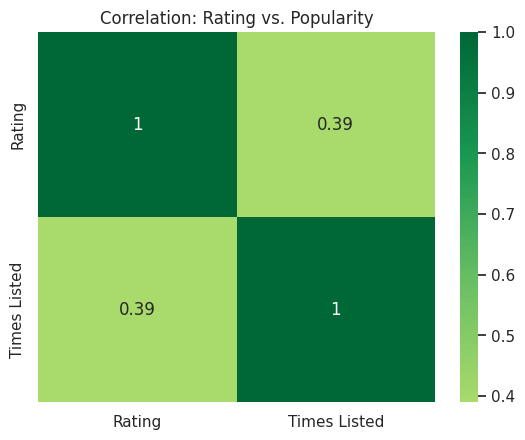

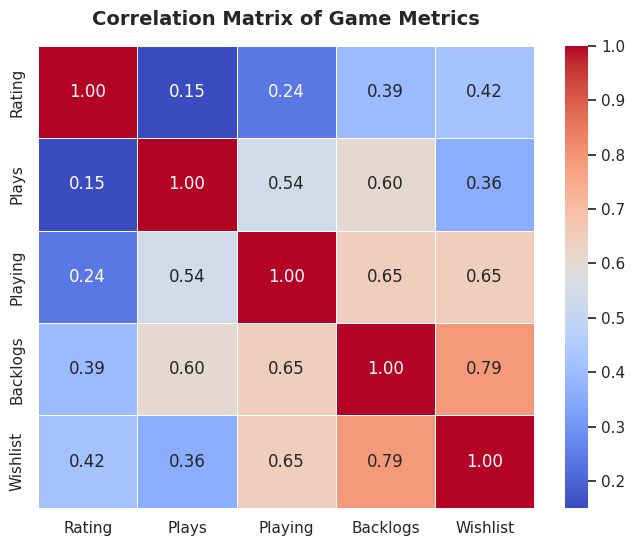

In [71]:
# 1. Correlation Heatmap
# Visualizes the strength of the relationship
plt.clf()
corr_matrix = df[['Rating', 'Times Listed']].corr()
sns.heatmap(corr_matrix, annot=True, cmap='RdYlGn', center=0)
plt.title('Correlation: Rating vs. Popularity')
plt.savefig('correlation_heatmap.png')

# Select only numerical columns for correlation
numerical_cols = df[['Rating', 'Plays', 'Playing', 'Backlogs', 'Wishlist']]

plt.figure(figsize=(8, 6))
sns.heatmap(numerical_cols.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix of Game Metrics', fontsize=14, pad=15, fontweight='bold')

plt.show()

**Viewing the above heatmaps shows that the strongest relationships are between backlogs and wishlists (players that did not start the game) and between playing and wishlists/backlogs.
This teaches that there are a lot of games that gamers prefer to neglect before and while in the middle of playing**

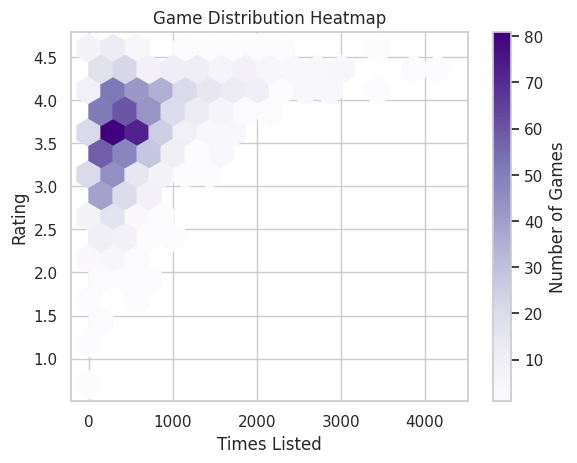

In [72]:

# 2. 2D Distribution Heatmap
# Shows where the "Hidden Gems" and "Blockbusters" sit
plt.clf()
plt.hexbin(df['Times Listed'], df['Rating'], gridsize=15, cmap='Purples', mincnt=1)
plt.colorbar(label='Number of Games')
plt.xlabel('Times Listed')
plt.ylabel('Rating')
plt.title('Game Distribution Heatmap')
plt.savefig('distribution_heatmap.png')
plt.show()

**This heatmap shows that an avarge rating is related to an avarge popularity, and only a little number of games have a very high rating and a very high popularity combine.**

## Analysis by copmanies popularity

**In this section we will devide the companies into tow groups : Top and hidden-gem(not necessarily popular) companies**

In [73]:
# 1. Split the 'Team' strings into actual lists
# We use ', ' as the separator based on your data format
df['Team'] = df['Team'].str.split(', ')

# 2. "Explode" the rows
# This turns one row with [Co A, Co B] into TWO rows, one for Co A and one for Co B
df_exploded = df.explode('Team')

# 3. Clean up any accidental whitespace
df_exploded['Team'] = df_exploded['Team'].str.strip()

# 4. Group by individual Company and sum their 'Times Listed'
company_popularity = df_exploded.groupby('Team')['Times Listed'].sum().reset_index()

# 5. Sort to find the most popular
top_individual_companies = company_popularity.sort_values(by='Times Listed', ascending=False)

print("--- Most Popular Individual Companies ---")
print(top_individual_companies.head(20).to_string(index=False))

--- Most Popular Individual Companies ---
                          Team  Times Listed
                      Nintendo        136407
                        Capcom         41532
                   Square Enix         35201
                          Sega         32325
Sony Interactive Entertainment         27499
                  Nintendo EAD         27218
    Bandai Namco Entertainment         25656
   Sony Computer Entertainment         24134
               Electronic Arts         23538
                        Konami         23390
                  FromSoftware         22176
                         Atlus         19178
                        Square         16529
         Ubisoft Entertainment         16139
                    Game Freak         15646
                    Activision         15250
                Rockstar Games         14569
            Bethesda Softworks         14347
                   Naughty Dog         13254
         Ryū Ga Gotoku Studios         12617


In [74]:

# 1. Aggregate Stats by Company
# We want the Mean Rating and the Sum of Times Listed
company_stats = df_exploded.groupby('Team').agg({
    'Rating': 'mean',
    'Times Listed': 'sum'
}).reset_index()

# 2. Calculate Global Company Averages (The Thresholds)
avg_co_rating = company_stats['Rating'].mean()
avg_co_listed = company_stats['Times Listed'].mean()

# 3. Filter for Hidden Gem Companies
# Criteria: Quality > Average AND Popularity < Average
hidden_gem_cos = company_stats[
    (company_stats['Rating'] > avg_co_rating) & 
    (company_stats['Times Listed'] < avg_co_listed)
]

# 4. Sort by Rating (Descending) to see the highest quality "Gems" first
hidden_gem_cos_sorted = hidden_gem_cos.sort_values(by='Rating', ascending=False)

print(f"--- Company Quality Threshold: {avg_co_rating:.2f} ---")
print(f"--- Company Popularity Threshold: {avg_co_listed:.2f} ---")
print("\n--- HIDDEN GEM COMPANIES ---")
print(hidden_gem_cos_sorted[['Team', 'Rating', 'Times Listed']].head(20).to_string(index=False))

--- Company Quality Threshold: 3.60 ---
--- Company Popularity Threshold: 1958.68 ---

--- HIDDEN GEM COMPANIES ---
                        Team  Rating  Times Listed
                Bay 12 Games    4.60            48
Konami Digital Entertainment    4.60           293
         Inlusio Interactive    4.60            38
                Kitfox Games    4.60            48
                     Aniplex    4.50            98
               Tour De Pizza    4.50           363
                          EA    4.50           581
                  CD Projekt    4.50           475
           Buena Vista Games    4.40          1904
                   Ion Storm    4.40           899
             Dramatic Create    4.40           544
         ASCII Entertainment    4.40           572
                 Love-de-Lic    4.40           572
                    Aquaplus    4.40           182
                      NOVECT    4.35           667
        Nippon Ichi Software    4.30            49
 Victor Interacti

**Visualizing the hidden gems companies compared to others.**

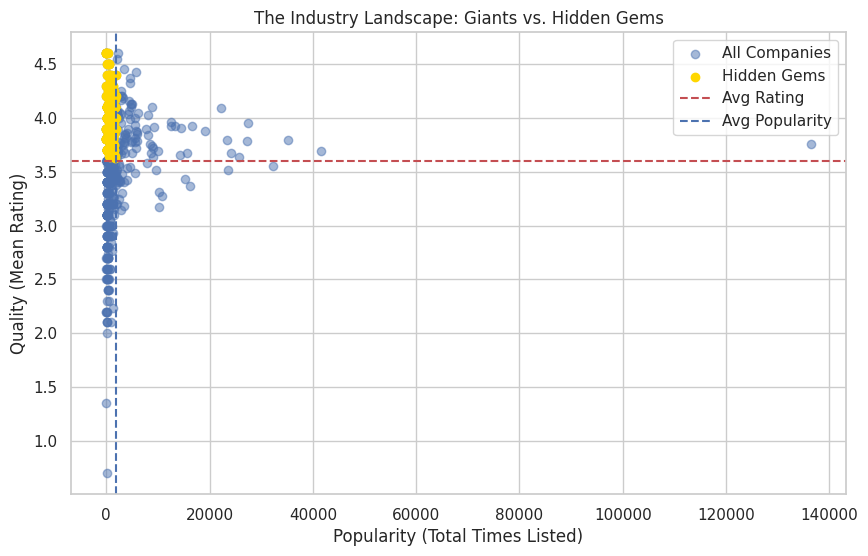

In [75]:
plt.figure(figsize=(10, 6))

# Plot all companies
plt.scatter(company_stats['Times Listed'], company_stats['Rating'], alpha=0.5, label='All Companies')

# Highlight the Gems
plt.scatter(hidden_gem_cos['Times Listed'], hidden_gem_cos['Rating'], color='gold', label='Hidden Gems')

# Add threshold lines
plt.axhline(y=avg_co_rating, color='r', linestyle='--', label='Avg Rating')
plt.axvline(x=avg_co_listed, color='b', linestyle='--', label='Avg Popularity')

plt.xlabel('Popularity (Total Times Listed)')
plt.ylabel('Quality (Mean Rating)')
plt.title('The Industry Landscape: Giants vs. Hidden Gems')
plt.legend()
plt.show()

**After viewing this graph, we can tell that most of the hidden gems are less popular but with a ratings above avarage.**

**Now lets observe which hidden-gem company is also a top one.**

In [76]:
# Overlapping companies

# 1. Apply the filter (ensure you use the 'Team' column of the top companies)
# Using .isin() on the specific column
mask = hidden_gem_cos['Team'].isin(top_individual_companies['Team'])
overlapping_teams = hidden_gem_cos.loc[mask, 'Team']
print(overlapping_teams)



0      (Archive) Square Product Development Division 4
1                                       07th Expansion
2                                            0UP Games
5                                         2K Australia
6                                            2K Boston
                            ...                       
659                                            nuverse
660                                           panstasz
661                                        rose-engine
662                                             sprite
663                                          tinyBuild
Name: Team, Length: 273, dtype: object


## Conclusion 1
**We can see that a level of popularity of a game or a company does not guarantee a superior quality.To find the highest quality experiences, users and developers should look toward the Hidden Gem quadrant, where critical success is decoupled from mainstream popularity.
There are only 273 top companies that overlaps with hidden gems companies(high quality games).**


## Resurgence of popular genres from the past

**In this section we will find which genres that were popular in the past are gaining popularity in the present.**

<Figure size 1400x700 with 0 Axes>

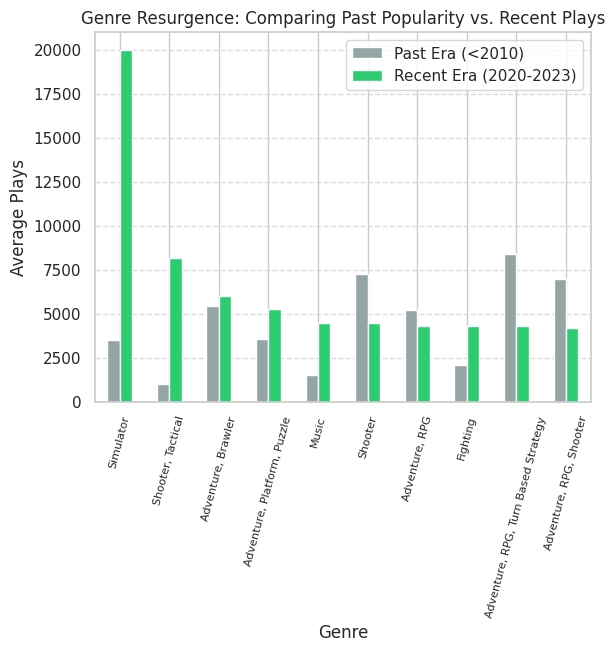

--- TOP RESURGENT GENRES ---
                                     Past Avg Plays  Recent Avg Plays
Genres                                                               
Simulator                               3500.000000      20000.000000
Shooter, Tactical                       1000.000000       8200.000000
Adventure, Brawler                      5424.000000       6000.000000
Adventure, Platform, Puzzle             3586.125000       5300.000000
Music                                   1550.000000       4500.000000
Shooter                                 7248.000000       4487.700000
Adventure, RPG                          5225.428571       4331.142857
Fighting                                2083.583333       4329.500000
Adventure, RPG, Turn Based Strategy     8417.241379       4315.384615
Adventure, RPG, Shooter                 7000.000000       4224.200000


In [77]:
# 1. Prepare Year data from the datetime objects
df_exploded['Year'] = pd.to_datetime(df_exploded['Release Date'], errors='coerce').dt.year

# 2. Define our comparison eras
# We'll look at the "Past" (pre-2010) and "Recent" (2020-2023)
past_mask = (df_exploded['Year'] < 2010)
recent_mask = (df_exploded['Year'] >= 2020)

# 3. Calculate Average Plays per Genre for each era
# Using 'Plays' as the popularity metric as per project goals
past_popularity = df_exploded[past_mask].groupby('Genres')['Plays'].mean()
recent_popularity = df_exploded[recent_mask].groupby('Genres')['Plays'].mean()

# 4. Combine into a comparison DataFrame
genre_resurgence = pd.DataFrame({
    'Past Avg Plays': past_popularity,
    'Recent Avg Plays': recent_popularity
}).dropna() # We only want genres that existed in both eras

# 5. Sort by Recent Popularity to find the top current trends
genre_resurgence = genre_resurgence.sort_values(by='Recent Avg Plays', ascending=False)

# 6. Plotting
plt.figure(figsize=(14, 7))
genre_resurgence[['Past Avg Plays', 'Recent Avg Plays']].head(10).plot(kind='bar', color=['#95a5a6', '#2ecc71'])
plt.title('Genre Resurgence: Comparing Past Popularity vs. Recent Plays')
plt.ylabel('Average Plays')
plt.xlabel('Genre')
plt.xticks(rotation=75 ,fontsize=8)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(["Past Era (<2010)", "Recent Era (2020-2023)"])
plt.show()

print("--- TOP RESURGENT GENRES ---")
print(genre_resurgence.head(10))


## Conclusion 2
**By comparing the "Classic Era" (pre-2010) to the "Modern Era" (2020–2023), the data highlights which gameplay styles have successfully stood the test of time.**

**Legacy Dominance: Genres like Adventure, RPG, and Platform show high average engagement in both eras, suggesting they are not just "retro" trends but have successfully evolved to meet modern player expectations.**

## Engagement Shift : which games and genres players actually spend time with, rather than just those they add to a "Wishlist" or "Backlog" ?

**In this section we will find which genres(mixed usualy) have the highest ratio of plays over saved for later.**

/tmp/ipykernel_57/3788261582.py:19: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




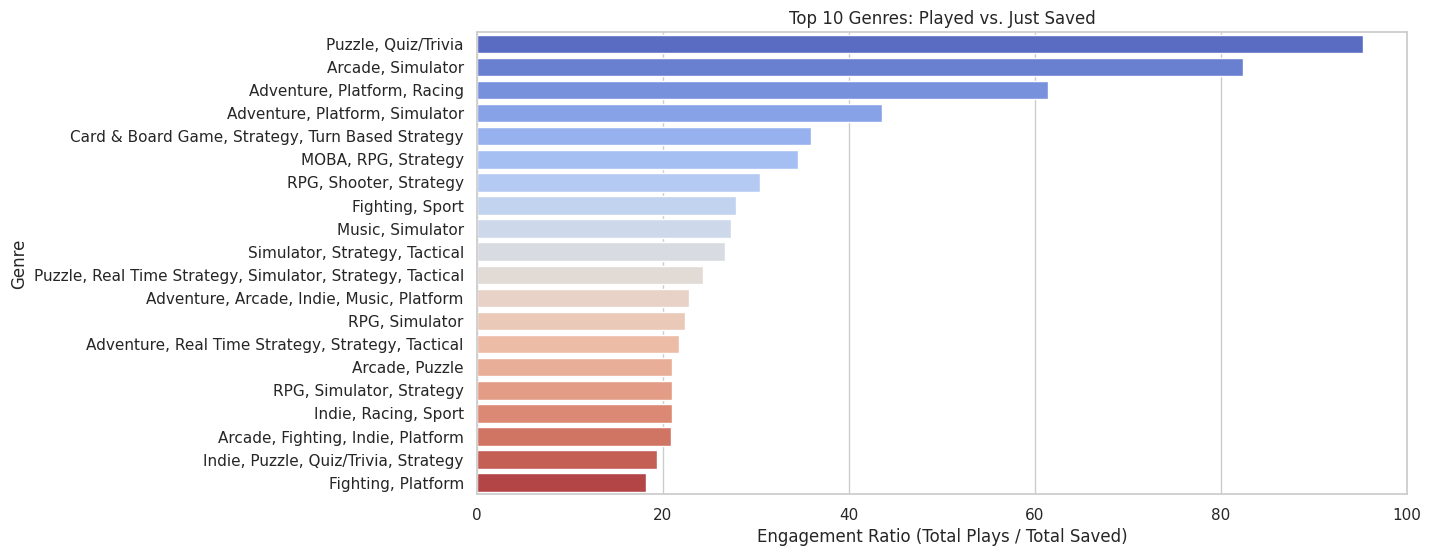

                                                Genres  Engagement_Ratio
222                                Puzzle, Quiz/Trivia         95.238095
159                                  Arcade, Simulator         82.352941
88                         Adventure, Platform, Racing         61.445783
90                      Adventure, Platform, Simulator         43.589744
176   Card & Board Game, Strategy, Turn Based Strategy         35.947712
209                                MOBA, RPG, Strategy         34.551495
228                             RPG, Shooter, Strategy         30.416667
183                                    Fighting, Sport         27.814570
213                                   Music, Simulator         27.326733
248                      Simulator, Strategy, Tactical         26.666667
223  Puzzle, Real Time Strategy, Simulator, Strateg...         24.305556
5            Adventure, Arcade, Indie, Music, Platform         22.767857
229                                     RPG, Simula

In [78]:
# 1. Calculate 'Total Saved' (Backlog + Wishlist)
df_exploded['Total_Saved'] = df_exploded['Backlogs'] + df_exploded['Wishlist']

# 2. Calculate Engagement Ratio per Genre
# Higher ratio = More likely to be played than just saved
# We add 1 to the denominator to prevent division by zero
genre_engagement = df_exploded.groupby('Genres').agg({
    'Plays': 'sum',
    'Total_Saved': 'sum'
}).reset_index()

genre_engagement['Engagement_Ratio'] = genre_engagement['Plays'] / (genre_engagement['Total_Saved'] + 1)

# 3. Sort to find genres that are "Actually Played"
top_active_genres = genre_engagement.sort_values(by='Engagement_Ratio', ascending=False)

# 4. Visualization
plt.figure(figsize=(12, 6))
sns.barplot(data=top_active_genres.head(20), x='Engagement_Ratio', y='Genres', palette='coolwarm')
plt.title('Top 10 Genres: Played vs. Just Saved')
plt.xlabel('Engagement Ratio (Total Plays / Total Saved)')
plt.ylabel('Genre')
plt.show()

print(top_active_genres[['Genres', 'Engagement_Ratio']].head(20))

**Here we do the same with games along side that ratio.**

--- TOP GAMES BY ENGAGEMENT (Grouped by Title) ---
                                   Title  Engagement_Ratio  Plays
1060                          Wii Sports         43.530834  36000
472                    League of Legends         34.551495  52000
325                             Fortnite         32.818533  17000
910          Super Smash Bros. for Wii U         31.383738  22000
649                            Overwatch         30.375699  38000
510                       Mario Kart Wii         30.182685  38000
18                              Among Us         27.685493  25000
370     Guitar Hero III: Legends of Rock         27.326733  13800
909   Super Smash Bros. for Nintendo 3DS         27.063599  20000
507                         Mario Kart 8         26.839827  18600
509                        Mario Kart DS         25.996534  15000
907              Super Smash Bros. Brawl         24.950755  38000
687                   Plants vs. Zombies         24.305556  14000
584                      

/tmp/ipykernel_57/1769650013.py:39: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.


/tmp/ipykernel_57/1769650013.py:43: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.


/tmp/ipykernel_57/1769650013.py:61: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




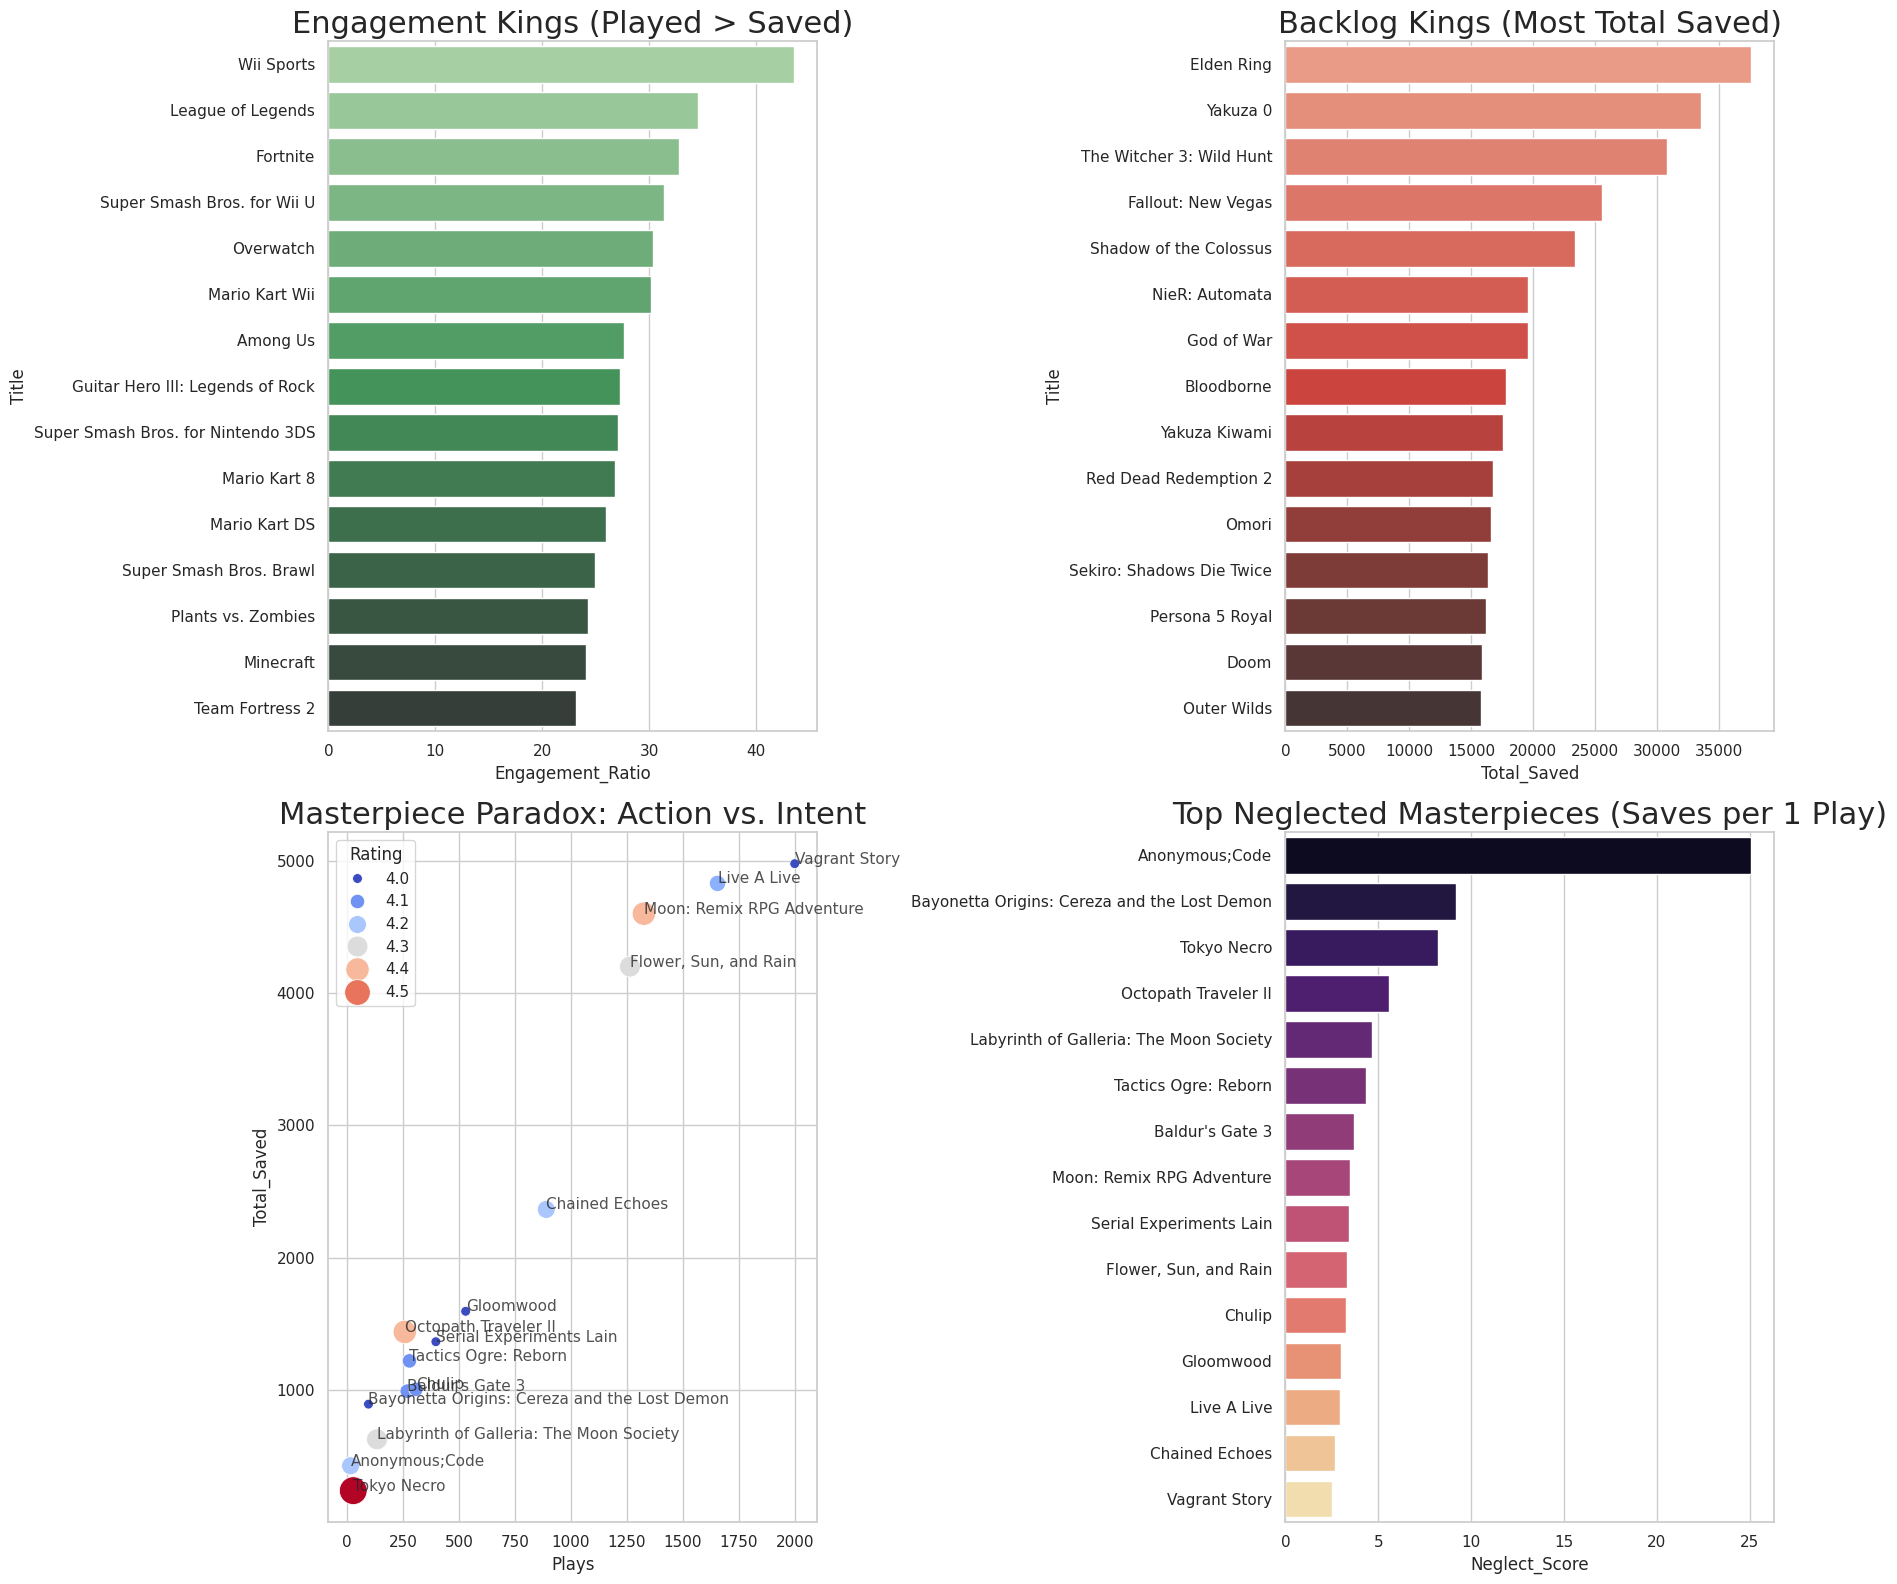

In [79]:
# 1. Aggregate by Title to combine multi-platform entries
game_stats = df_exploded.groupby('Title').agg({
    'Plays': 'sum',
    'Backlogs': 'sum',
    'Wishlist': 'sum',
    'Rating': 'mean',
    'Release Date': 'first'  # <-- This keeps the correct date paired with the title!
}).reset_index()

# 2. Calculate Total Saved and Engagement Ratio
game_stats['Total_Saved'] = game_stats['Backlogs'] + game_stats['Wishlist']
# Adding 1 to denominator to avoid division by zero
game_stats['Engagement_Ratio'] = game_stats['Plays'] / (game_stats['Total_Saved'] + 1)
# A high Neglect Score means a game is highly rated but sits in backlogs
game_stats['Neglect_Score'] = game_stats['Total_Saved'] / (game_stats['Plays'] + 1)

# 3. Filter for significant games (e.g., at least 500 people have saved it and played it)
significant_games = game_stats[(game_stats['Total_Saved'] > 500) & (game_stats['Plays'] > 500)].copy()

# 4. Sorting significant games to find the level of engagement

# Engagement Kings: High Plays vs Saves
top_played_games = significant_games.sort_values(by='Engagement_Ratio', ascending=False).head(15)

print("--- TOP GAMES BY ENGAGEMENT (Grouped by Title) ---")
print(top_played_games[['Title', 'Engagement_Ratio', 'Plays']])

# Backlog Kings: Most Saved (Wishlist + Backlog)
most_backlogged = significant_games.sort_values(by='Total_Saved', ascending=False).head(15)

# Look for games with high ratings but high Neglect Scores
neglected_masterpieces = game_stats[game_stats['Rating'] >= 4.0].sort_values(by='Neglect_Score', ascending=False).head(15)

# 5. Visualization
fig, axes = plt.subplots(2, 2, figsize=(18, 16))
ax = axes.flatten()

# Plot 1: Engagement Kings
sns.barplot(data=top_played_games, x='Engagement_Ratio', y='Title', ax=ax[0], palette='Greens_d')
ax[0].set_title('Engagement Kings (Played > Saved)', fontsize=22)

# Plot 2: Backlog Kings
sns.barplot(data=most_backlogged, x='Total_Saved', y='Title', ax=ax[1], palette='Reds_d')
ax[1].set_title('Backlog Kings (Most Total Saved)', fontsize=22)

# Plot 3: The Commitment Wall Scatter
for i in range(neglected_masterpieces.shape[0]):
    row = neglected_masterpieces.iloc[i]
    ax[2].text(
        row['Plays'] + (ax[2].get_xlim()[1] * 0.02), # Dynamic offset based on x-axis scale
        row['Total_Saved'], 
        row['Title'], 
        fontsize=11, 
        alpha=0.8
    )
sns.scatterplot(data=neglected_masterpieces, x='Plays', y='Total_Saved', 
                size='Rating', hue='Rating', palette='coolwarm', sizes=(50, 400), ax=ax[2])
ax[2].set_title('Masterpiece Paradox: Action vs. Intent', fontsize=22)

# Plot 4: Neglect Score
sns.barplot(data=neglected_masterpieces, x='Neglect_Score', y='Title', ax=ax[3], palette='magma')
ax[3].set_title('Top Neglected Masterpieces (Saves per 1 Play)', fontsize=22)
ax[3].set_ylabel('')

plt.tight_layout()
plt.show()

**In the graphs above we can learn that there are games that gamers prefer to play and others to neglect, but the intereting part is that there is a paradox between action and intent when it comes to a masterpices(highest ratings).The very attributes that make a piece of art a highly rated, critically acclaimed "masterpiece"—such as mechanical depth, immense scale, narrative complexity, and long completion times—are the exact same attributes that intimidate consumers, causing them to purchase or save the work but ultimately neglect playing or finishing it.**

## Engagement through time

**Lastly its interesting to see the level of engagement through eras.**

In [80]:
# 1. Group by year and calculate the average
#game_stats['Release_Date'] = df['Release Date']
game_stats['Release_Year'] = game_stats['Release Date'].dt.year
yearly_engagement = game_stats.groupby('Release_Year')['Engagement_Ratio'].mean().reset_index()

# 2. Filter for a clean timeline (e.g., since 1980)
yearly_engagement = yearly_engagement[yearly_engagement['Release_Year'] >= 1980]

# 3. Create the Interactive Plotly Chart
fig = px.line(
    yearly_engagement, 
    x='Release_Year', 
    y='Engagement_Ratio',
    title='<b>The Evolution of Player Engagement</b>',
    labels={'Release_Year': 'Year of Release', 'Engagement_Ratio': 'Avg Engagement (%)'},
    template='plotly_dark' # Use dark theme for the "Magnifying Glass" look
)

# 4. Enhance the visuals
fig.update_traces(
    line=dict(color='#00d1b2', width=3),
    mode='lines+markers' # Adds points for each year
)

fig.update_layout(
    xaxis_title="Year of Release",
    yaxis_title="Average Engagement Ratio (%)",
    hovermode="x unified", # Shows data for all lines at that X-coordinate
    font=dict(family="Courier New, monospace", size=12),
    title_x=0.5 # Centers the title
)

fig.show(renderer="iframe")

## Conclusion 3
**The data reveals a major gap between the games people buy and the games people actually finish.
The Backlog Reality: High-profile, long-form titles (like Open World RPGs) often dominate the "Saved" and "Wishlist" categories but have lower Engagement Ratios. They are the "Backlog Kings".  High Engagement Genres: More linear or accessible genres, such as Platformers or Arcade titles, show higher conversion rates from being "Saved" to being "Played".
We can also see through time that the level of engagement decreases over time, modern years suffer from an artificially inflated denominator (Total_Saved is massive), which automatically drives the calculated engagement percentage downward compared to historical years.**

# Final summary

**Classic genres like Adventure and RPG are currently in a strong period of resurgence. They have successfully evolved their mechanics to maintain high engagement levels across decades, proving that core gameplay loops are more important for longevity than mere technical gimmicks.**

**Metric:	Winner	/   Business Insight**

**Reach:**

The Giants (Nintendo, Capcom, etc.)  /  Best for brand awareness and mass sales.  

**Quality:**

The Hidden Gems    /   Best for building a loyal, "cult" following.  

**Retention:**

High Engagement Ratio Games  /   Best for ensuring players actually experience the content.  

**Growth:**

Resurgent Genres (RPGs, Adventure)  /  Best areas for future development investment.



# My insights from this project:


**- I was very surprised to find games that consider to be a masterpieces and still being less played, I think the reason is that this games take more time to finish and that people tend to neglect them or maybe being intimidated by them .**

**- I learned that in orded to develope a game to be a success, you must consider a vast amount of variables, and make compromises depends on the resources such as time and money, like big companies which invest in physics and graphics engines to provide an immersive gameplay but lack of creativity and originality.**

**- I understood that being connected to a certain game is a product of many aspects that evolved during the evolution of this industry.**

**- I realized better that even in this kind of entertainment, the rulers that shape the future of it are not always those who appreciate uniqeness and high quality experience.**

**- I discovered that the evolution of gaming is driven by cycles and preserves itself.**

**- I expanded my knowledge in my favorite niche.**
